In [99]:
import pandas as pd
import numpy as np
# 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# 
from special_use_classes import OutlierHandling
import special_use_classes
import importlib
importlib.reload(special_use_classes)
# 
import matplotlib.pyplot as plt
import seaborn as sns
# 
outlier_handler = OutlierHandling()

### data loading

In [100]:
mydata = pd.read_csv(r'data\BankChurners.csv')

data exploration

In [101]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

dropping the last two columns

In [102]:
columns_list = mydata.columns.tolist()
print(columns_list)
df = mydata.drop(columns=columns_list[-2:])
df = df.drop(columns='CLIENTNUM')

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [103]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### we have many outliers in our data

<Axes: >

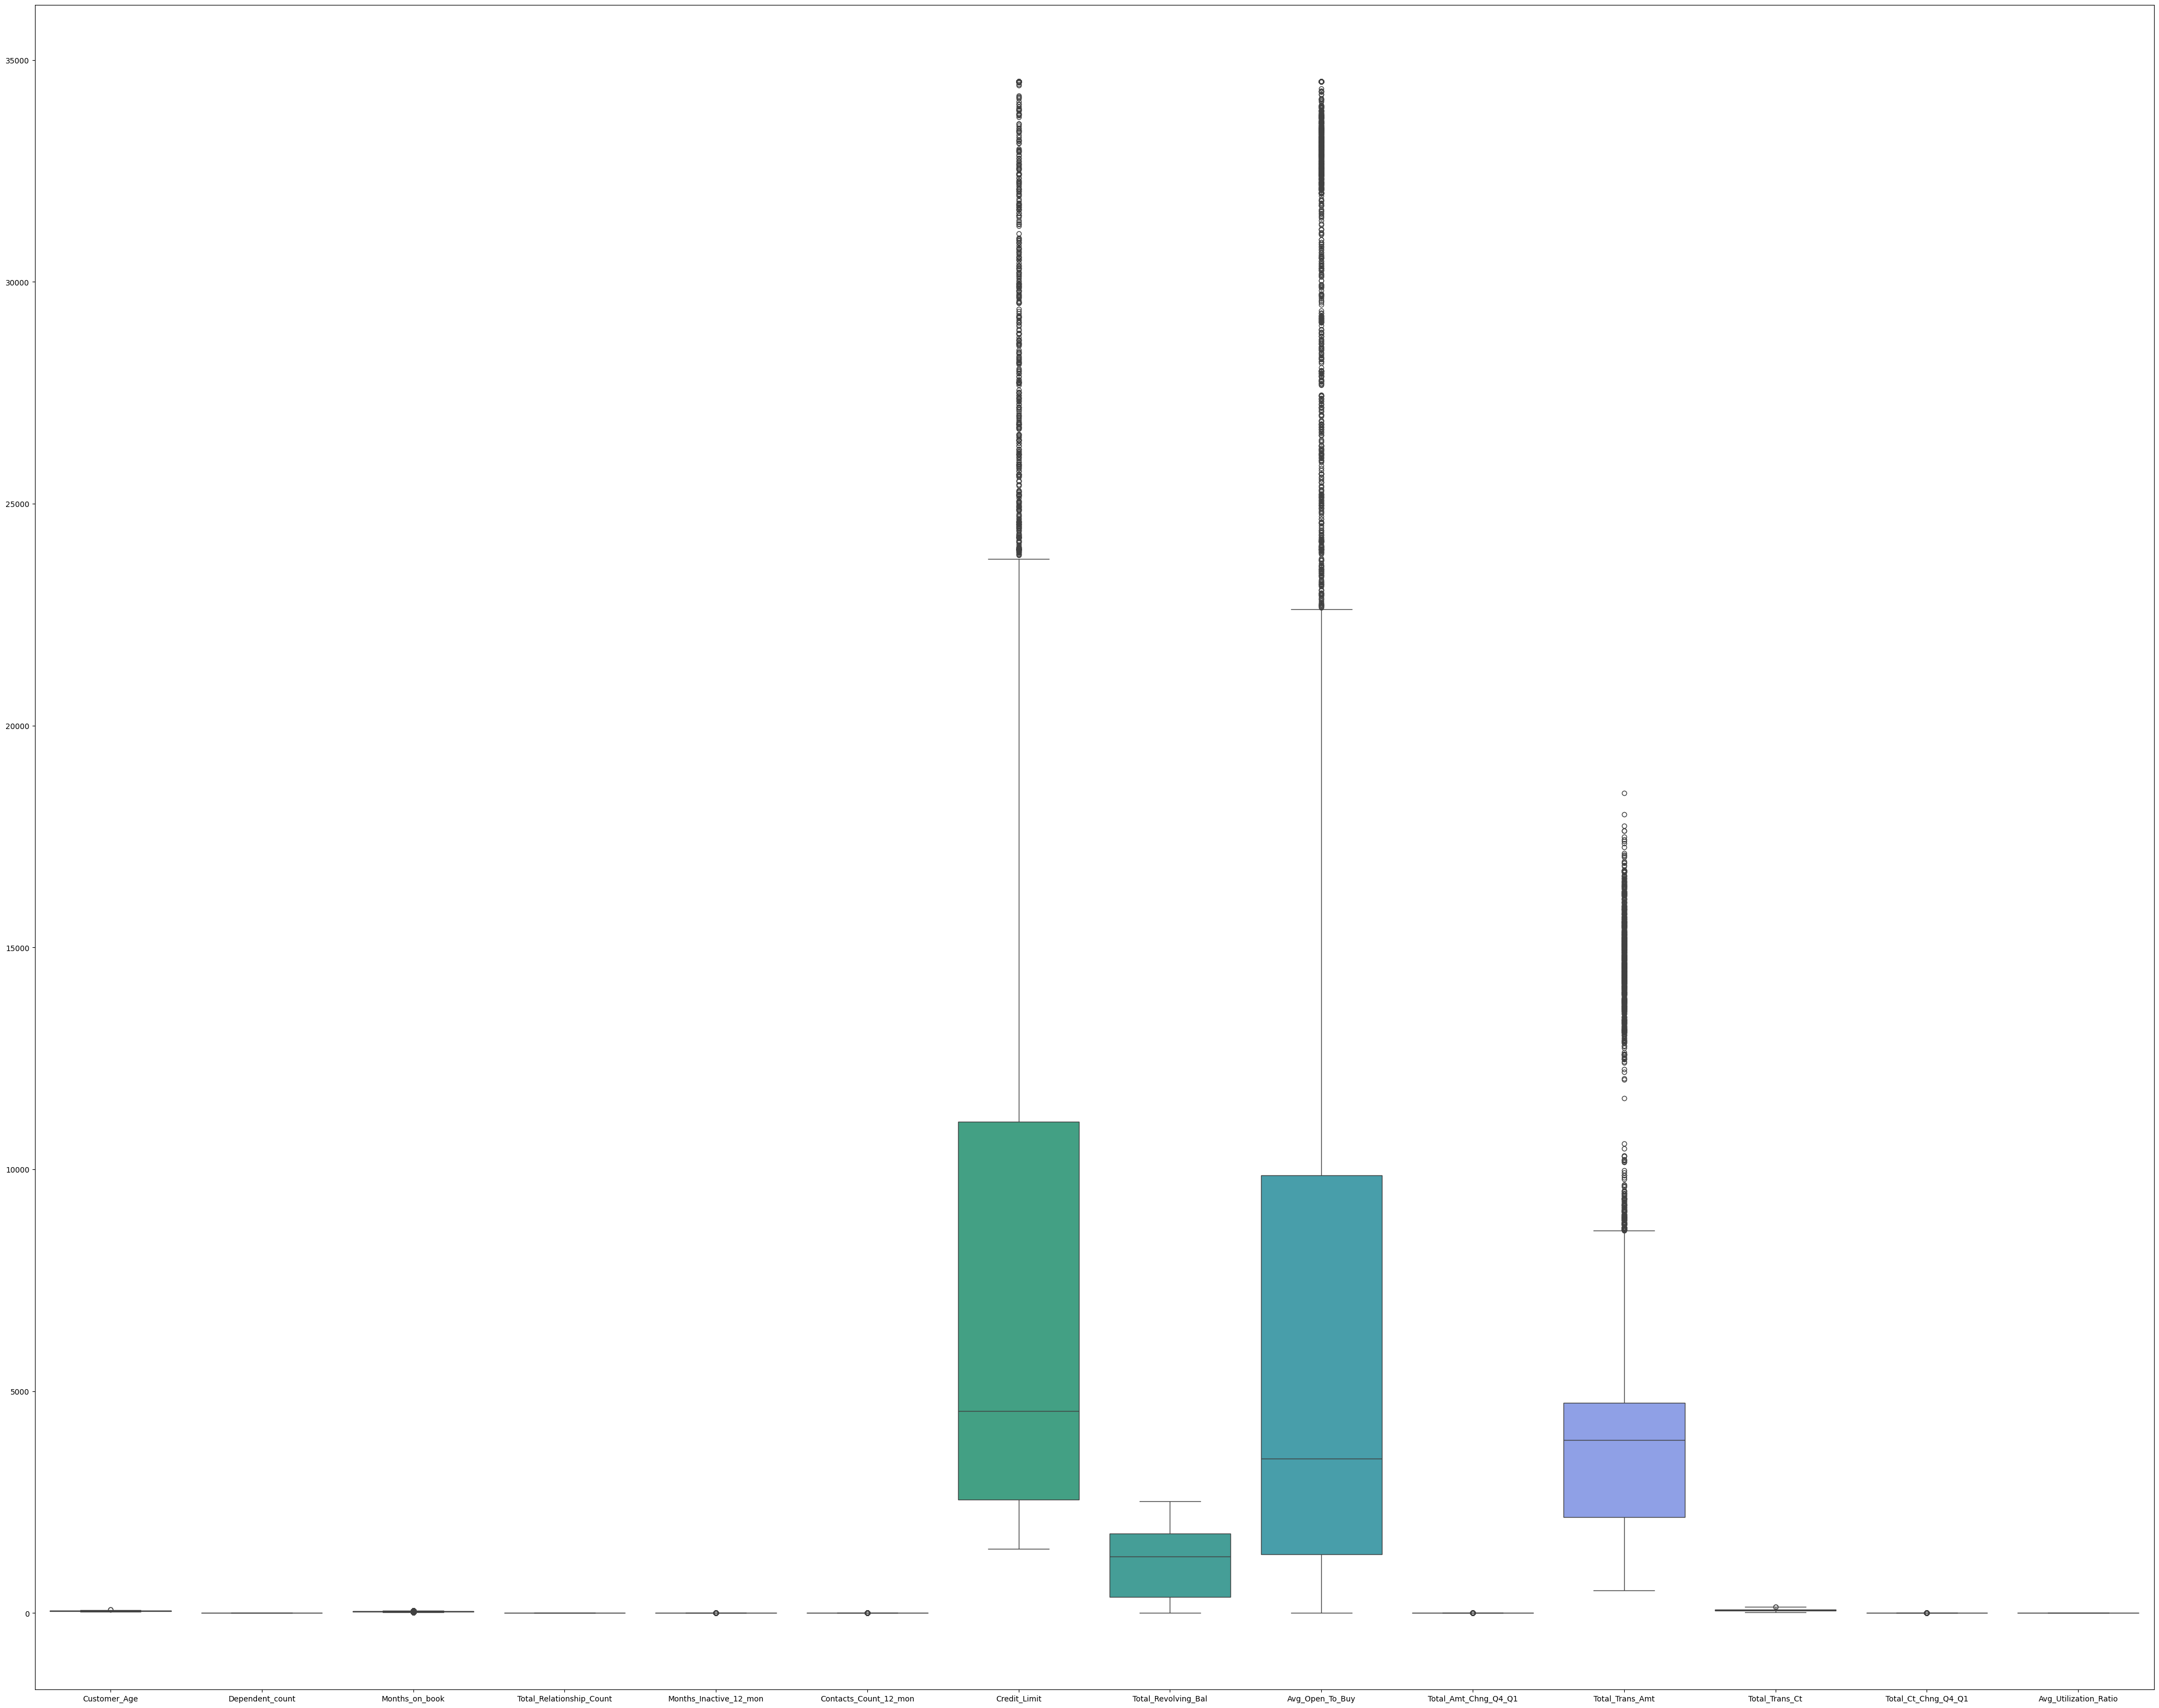

In [104]:
plt.figure(figsize=(50,40))
sns.boxplot(df)

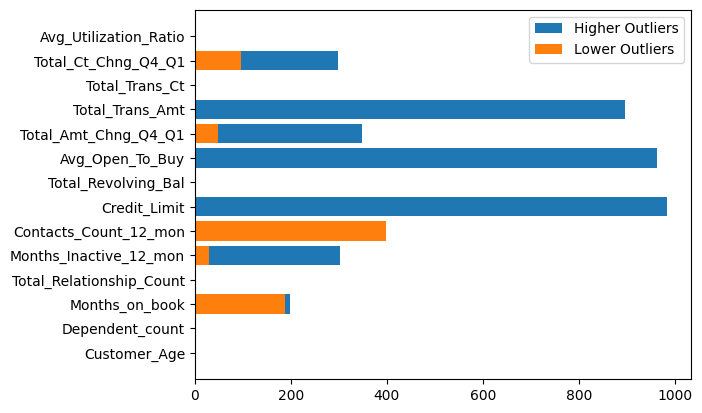

Customer_Age: 2, Customer_Age: 0, Total: 2
________________

Months_on_book: 198, Months_on_book: 188, Total: 386
________________

Months_Inactive_12_mon: 302, Months_Inactive_12_mon: 29, Total: 331
________________

Contacts_Count_12_mon: 230, Contacts_Count_12_mon: 399, Total: 629
________________

Credit_Limit: 984, Credit_Limit: 0, Total: 984
________________

Avg_Open_To_Buy: 963, Avg_Open_To_Buy: 0, Total: 963
________________

Total_Amt_Chng_Q4_Q1: 348, Total_Amt_Chng_Q4_Q1: 48, Total: 396
________________

Total_Trans_Amt: 896, Total_Trans_Amt: 0, Total: 896
________________

Total_Trans_Ct: 2, Total_Trans_Ct: 0, Total: 2
________________

Total_Ct_Chng_Q4_Q1: 298, Total_Ct_Chng_Q4_Q1: 96, Total: 394
________________



In [105]:
outlier_handler = OutlierHandling()

outlier_handler.plot(df)
outlier_handler.count_outliers_df(df)
# outlier_handler.display_outliers_df(df)


### outliers are too many, hence that we shouldn't just remove because its normal for banking to have high paying customers
##### we should go with log transformation for highly skewed (most outliers) features instead

In [106]:
thing = df.skew(numeric_only=True).tolist()
skews = df.skew(numeric_only=True).sort_values()
high_skew = skews[skews.abs() > 1]
high_skew

Avg_Open_To_Buy         1.661697
Credit_Limit            1.666726
Total_Amt_Chng_Q4_Q1    1.732063
Total_Trans_Amt         2.041003
Total_Ct_Chng_Q4_Q1     2.064031
dtype: float64

<BarContainer object of 14 artists>

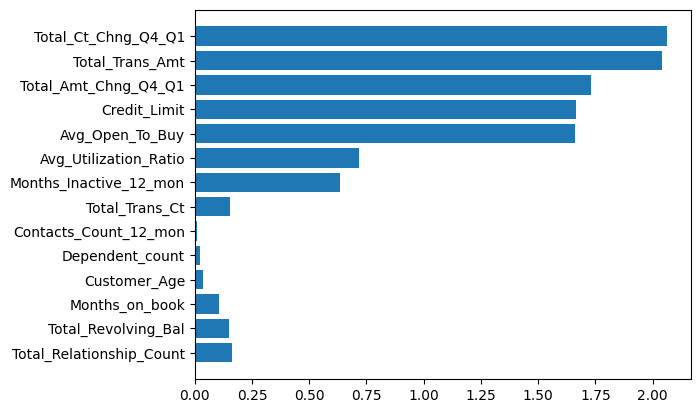

In [107]:
plt.barh(skews.abs().index, skews.abs().values)

In [108]:
thing

[-0.033605016317173456,
 -0.020825535616339912,
 -0.10656535989402989,
 -0.16245241498173682,
 0.6330611289713137,
 0.011005626218976492,
 1.666725807993647,
 -0.14883725028007228,
 1.6616965459311595,
 1.7320634114286038,
 2.0410034025756936,
 0.15367306849872275,
 2.0640305679077477,
 0.7180079967731994]

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [110]:
high_skewed_cols = high_skew.index.tolist()
high_skewed_cols

['Avg_Open_To_Buy',
 'Credit_Limit',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Ct_Chng_Q4_Q1']

In [111]:
# transformation
cleaned_df = df
for i in high_skewed_cols:
    cleaned_df[i] = np.log1p(df[i])
cleaned_df.skew(numeric_only=True)

Customer_Age               -0.033605
Dependent_count            -0.020826
Months_on_book             -0.106565
Total_Relationship_Count   -0.162452
Months_Inactive_12_mon      0.633061
Contacts_Count_12_mon       0.011006
Credit_Limit                0.457303
Total_Revolving_Bal        -0.148837
Avg_Open_To_Buy            -0.095298
Total_Amt_Chng_Q4_Q1        0.648440
Total_Trans_Amt             0.262780
Total_Trans_Ct              0.153673
Total_Ct_Chng_Q4_Q1         0.510172
Avg_Utilization_Ratio       0.718008
dtype: float64

<BarContainer object of 14 artists>

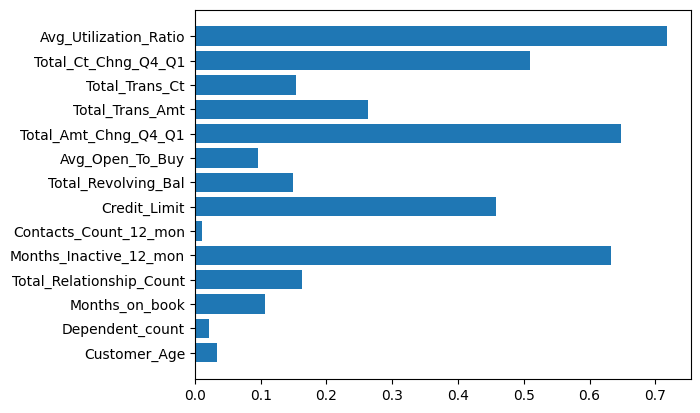

In [112]:
temp = cleaned_df.skew(numeric_only=True).abs()

plt.barh(temp.index, temp.values)

# Customer Churn Prediction

In [113]:
cleaned_df['Attrition_Flag'].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [114]:
# lets scale and encode

In [115]:
encoded_df = pd.get_dummies(cleaned_df.copy())
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Customer_Age                      10127 non-null  int64  
 1   Dependent_count                   10127 non-null  int64  
 2   Months_on_book                    10127 non-null  int64  
 3   Total_Relationship_Count          10127 non-null  int64  
 4   Months_Inactive_12_mon            10127 non-null  int64  
 5   Contacts_Count_12_mon             10127 non-null  int64  
 6   Credit_Limit                      10127 non-null  float64
 7   Total_Revolving_Bal               10127 non-null  int64  
 8   Avg_Open_To_Buy                   10127 non-null  float64
 9   Total_Amt_Chng_Q4_Q1              10127 non-null  float64
 10  Total_Trans_Amt                   10127 non-null  float64
 11  Total_Trans_Ct                    10127 non-null  int64  
 12  Tota

<Axes: >

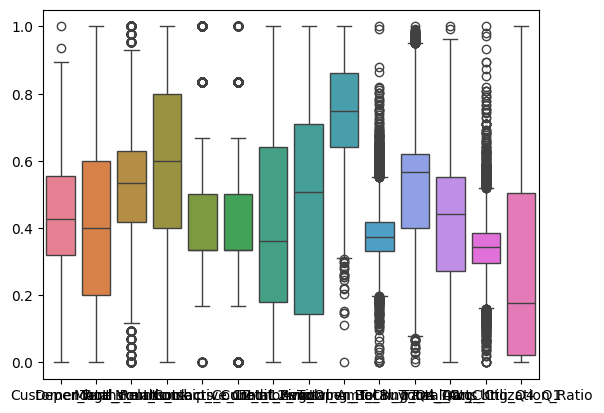

In [116]:
# lets scaling using pandas way
numeric_df = encoded_df.select_dtypes('number')
norm_df = (numeric_df-numeric_df.min()) / (numeric_df.max()-numeric_df.min())
sns.boxplot(norm_df)

In [117]:
num_cols = numeric_df.columns.tolist()
non_num_cols = list(set(encoded_df.columns.tolist()) - set(num_cols))
mydf = norm_df
mydf[non_num_cols] = encoded_df[non_num_cols]
mydf.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Attrition_Flag_Attrited Customer,Card_Category_Silver,Education_Level_Doctorate,Marital_Status_Single,Education_Level_Post-Graduate,Education_Level_Graduate,Education_Level_College,Gender_M,Education_Level_High School,Marital_Status_Divorced
0,0.404255,0.6,0.604651,0.8,0.166667,0.500000,0.685116,0.308701,0.882637,0.572624,...,False,False,False,False,False,False,False,True,True,False
1,0.489362,1.0,0.720930,1.0,0.166667,0.333333,0.549809,0.343266,0.829975,0.629714,...,False,False,False,True,False,True,False,False,False,False
2,0.531915,0.6,0.534884,0.6,0.166667,0.000000,0.272304,0.000000,0.744883,0.863830,...,False,False,False,False,False,True,False,True,False,False
3,0.297872,0.8,0.488372,0.4,0.666667,0.166667,0.262487,1.000000,0.584201,0.592570,...,False,False,False,False,False,False,False,False,True,False
4,0.297872,0.6,0.186047,0.8,0.166667,0.000000,0.373593,0.000000,0.780393,0.780127,...,False,False,False,False,False,False,False,True,False,False
